In [1]:
import pandas as pd
import numpy as np
import openpyxl as px

In [2]:
pd.set_option('display.max_rows', None)   # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full column content
pd.set_option('display.width', None)  # Don’t wrap columns

In [3]:
df = pd.read_excel("Baseline_Brazil_a.xlsx", sheet_name="Plan1") 
df = df.drop(columns=['pregnant', 'job', 'curso', 'geral_id', 
                      'year_entered', 'bmi_class', 'year',
                      'score_food_smile', 'score_subs_smile', 'score_PA_smile', 
                      'score_stress_smile', 'score_sleep_smile', 'score_social_smile', 
                      'score_envir_smile', 'scoretot_smile'])

courses = pd.read_excel("Untitled 1.ods", engine='odf')
df = pd.concat([df, courses], axis=1)

drop = [1, 2, 3]
df = df[~df['student_of'].isin(drop)]
df = df.drop(columns=['student_of'])

print(f"{df.shape[0]} rows, {df.shape[1]} columns")

CATEGORICAL_MAX_UNIQUE = 6

def is_integer_valued(series):
    non_null = series.dropna()
    if len(non_null) == 0:
        return False
    return np.issubdtype(non_null.dtype, np.floating) and (non_null == non_null.round()).all()

categorical_cols = []
numerical_cols   = []

for col in df.columns:
    s = df[col]
    if is_integer_valued(s) and s.nunique() <= CATEGORICAL_MAX_UNIQUE:
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

df['gad7_class'] = df['gad7_class'] + 1

print("Categorical columns:", categorical_cols)
print("Numerical columns  :", numerical_cols)

sexual_dicotomico_indexes = df[df['sexual_orientation'] == 0].index.tolist()
gender_dicotomico_indexes = df[df['gender_identity'] == 0].index.tolist()

df.describe()


6398 rows, 40 columns
Categorical columns: ['sex', 'gender_identity', 'sexual_orientation', 'ethnic_group', 'marital_status', 'student_accommodation', 'work', 'smile_2', 'smile_3', 'smile_5', 'smile_8', 'smile_9', 'smile_10', 'smile_11', 'smile_12', 'smile_13', 'smile_15', 'smile_17', 'smile_19', 'smile_25', 'smile_27', 'smile_28', 'smile_30', 'smile_31', 'smile_32', 'smile_34', 'smile_37', 'smile_40', 'smile_41', 'smile_42', 'smile_43', 'sedentary_behavior', 'sedentary_2', 'gad7_class']
Numerical columns  : ['age', 'bmi', 'income', 'university', 'gad7_score', 'course']


,age,sex,gender_identity,sexual_orientation,ethnic_group,bmi,marital_status,student_accommodation,work,income,university,smile_2,smile_3,smile_5,smile_8,smile_9,smile_10,smile_11,smile_12,smile_13,smile_15,smile_17,smile_19,smile_25,smile_27,smile_28,smile_30,smile_31,smile_32,smile_34,smile_37,smile_40,smile_41,smile_42,smile_43,sedentary_behavior,sedentary_2,gad7_score,gad7_class,course
count,6398.000000,6385.000000,6326.000000,6357.000000,6373.000000,6197.000000,6380.000000,6386.000000,6374.000000,5.827000e+03,6398.000000,6391.000000,6385.000000,6393.00000,6373.000000,6381.000000,6381.000000,6367.000000,6382.000000,6387.000000,6349.000000,6380.000000,6379.000000,6392.000000,6372.000000,6394.000000,6385.000000,6379.000000,6388.000000,6382.000000,6383.000000,6385.000000,6384.000000,6389.000000,6386.000000,6316.000000,6318.000000,5243.000000,5709.000000,6398.000000
mean,19.934511,0.396398,0.063231,0.697656,0.924212,23.371708,1.065517,0.981209,0.810323,1.030502e+04,6.727884,0.800970,1.679875,2.08306,2.421309,2.776211,2.810375,2.977540,1.539799,0.686238,1.981729,0.713950,1.311491,1.611859,1.252511,1.198780,2.391699,1.844960,1.961490,1.914134,2.246436,0.889272,0.449561,1.398341,1.766990,2.162445,1.044634,10.601373,0.497635,3.310566
std,3.214580,0.489187,0.338027,1.073956,0.980858,4.665010,0.507139,0.135797,0.392076,2.873748e+05,3.624238,0.920369,0.685472,0.76440,0.761992,0.606189,0.547229,0.181534,1.060126,0.959338,1.082882,0.958208,1.182478,0.837064,0.859153,0.897391,0.721076,0.895239,1.026083,0.953959,0.783662,0.914133,0.683018,0.817316,1.017104,1.011050,1.083020,5.484620,0.500038,2.280197
min,16.000000,0.000000,0.000000,0.000000,0.000000,12.818459,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,20.147972,1.000000,1.000000,1.000000,1.500000e+03,3.000000,0.000000,1.000000,2.00000,2.000000,3.000000,3.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,6.000000,0.000000,1.000000
50%,19.000000,0.000000,0.000000,0.000000,1.000000,22.587833,1.000000,1.000000,1.000000,2.800000e+03,7.000000,1.000000,2.000000,2.00000,3.000000,3.000000,3.000000,3.000000,1.000000,0.000000,2.000000,0.000000,1.000000,2.000000,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,1.000000,2.000000,2.000000,1.000000,10.000000,0.000000,3.000000
75%,20.000000,1.000000,0.000000,2.000000,2.000000,25.469387,1.000000,1.000000,1.000000,5.010500e+03,10.000000,1.000000,2.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,1.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,2.000000,3.000000,3.000000,2.000000,15.000000,1.000000,5.000000
max,42.000000,1.000000,2.000000,4.000000,5.000000,58.823528,4.000000,1.000000,1.000000,2.000000e+07,13.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,21.000000,1.000000,8.000000


In [4]:

# ── Regional grouping by university code ──────────────────────────────────────
# Codes 0–4 (alphabetical): 0=center-west, 1=north, 2=northeast, 3=south, 4=southeast
REGION_NAMES = ['center-west', 'north', 'northeast', 'south', 'southeast']

region_map = {
    1: 4, 12: 4, 13: 4,                   # southeast
    2: 2,  4: 2,  5: 2, 6: 2, 7: 2, 8: 2, # northeast
    3: 1,                                   # north
    11: 0,                                  # center-west
    9: 3, 10: 3,                            # south
}

df['region'] = df['university'].map(region_map).astype(int)

# Store original-df indexes per region code (used in cell 8 for per-region evaluation)
region_indexes = {
    code: df.index[df['region'] == code].tolist()
    for code in range(len(REGION_NAMES))
}

# Sanity check
print("Participants per region:")
for code, name in enumerate(REGION_NAMES):
    print(f"  {code} = {name}: {len(region_indexes[code])}")

print("\nUniversity → region code:")
print(
    df.groupby('university')['region']
    .first()
    .reset_index()
    .sort_values('university')
    .to_string(index=False)
)


Participants per region:
  0 = center-west: 347
  1 = north: 267
  2 = northeast: 3189
  3 = south: 1040
  4 = southeast: 1555

University → region code:
 university  region
          1       4
          2       2
          3       1
          4       2
          5       2
          6       2
          7       2
          8       2
          9       3
         10       3
         11       0
         12       4
         13       4


In [5]:
X = df.drop(columns=['gad7_class', 'gad7_score', 'university', 
                     'course', 'region'])
y = df["gad7_class"]

valid_mask = y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

if y.isna().any():
    raise ValueError("y contains NaN values after filtering.")

data_idx = X.index.to_numpy()

print(f"{X.shape[0]} rows, {X.shape[1]} columns")
X.describe()

5709 rows, 36 columns


,age,sex,gender_identity,sexual_orientation,ethnic_group,bmi,marital_status,student_accommodation,work,income,smile_2,smile_3,smile_5,smile_8,smile_9,smile_10,smile_11,smile_12,smile_13,smile_15,smile_17,smile_19,smile_25,smile_27,smile_28,smile_30,smile_31,smile_32,smile_34,smile_37,smile_40,smile_41,smile_42,smile_43,sedentary_behavior,sedentary_2
count,5709.000000,5699.000000,5650.000000,5671.000000,5686.000000,5532.000000,5692.000000,5697.000000,5689.000000,5.213000e+03,5705.000000,5699.000000,5705.000000,5690.000000,5695.000000,5698.000000,5687.000000,5696.000000,5703.000000,5673.000000,5694.000000,5696.000000,5705.000000,5686.000000,5706.000000,5698.000000,5695.000000,5702.000000,5695.000000,5697.000000,5700.000000,5699.000000,5702.000000,5702.000000,5704.000000,5705.000000
mean,19.930110,0.402702,0.065487,0.709222,0.932642,23.392283,1.064301,0.981043,0.809984,1.082793e+04,0.809991,1.688542,2.085013,2.427417,2.778753,2.811162,2.976789,1.537746,0.679642,1.977966,0.708465,1.295822,1.610342,1.246922,1.194357,2.387504,1.830202,1.948439,1.893415,2.243110,0.884211,0.443236,1.394248,1.765345,2.171634,1.037336
std,3.198938,0.490485,0.344332,1.081959,0.977963,4.677265,0.504847,0.136386,0.392348,3.037855e+05,0.923060,0.682243,0.762434,0.755658,0.605157,0.547356,0.183249,1.062563,0.957324,1.083783,0.957929,1.184072,0.837078,0.858023,0.897700,0.724504,0.897916,1.030055,0.960248,0.784583,0.912334,0.676329,0.818970,1.020749,1.008379,1.080641
min,16.000000,0.000000,0.000000,0.000000,0.000000,12.818459,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,20.153665,1.000000,1.000000,1.000000,1.500000e+03,0.000000,1.000000,2.000000,2.000000,3.000000,3.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,19.000000,0.000000,0.000000,0.000000,1.000000,22.600264,1.000000,1.000000,1.000000,2.800000e+03,1.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,1.000000,0.000000,2.000000,0.000000,1.000000,2.000000,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,1.000000,2.000000,2.000000,1.000000
75%,20.000000,1.000000,0.000000,2.000000,2.000000,25.476660,1.000000,1.000000,1.000000,5.000000e+03,1.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,2.000000,3.000000,3.000000,2.000000
max,42.000000,1.000000,2.000000,4.000000,5.000000,58.823528,4.000000,1.000000,1.000000,2.000000e+07,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000


In [6]:
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline

# Winsorize income at 99th percentile to remove data entry outliers
# (raw max = 20,000,000 BRL vs median ~2,800 — clearly erroneous)
income_cap = X['income'].quantile(0.99)
X['income'] = X['income'].clip(upper=income_cap)

shuffle_split = ShuffleSplit(n_splits=5, test_size=0.2, random_state=50)
splits = []

one_hotted = ['sex', 'gender_identity', 'sexual_orientation', 'ethnic_group',
               'marital_status', 'student_accommodation', 'work']  

num = ['age', 'income', 'sedentary_behavior', 'sedentary_2', 'smile_2','smile_3', 'bmi',
       'smile_5', 'smile_8', 'smile_9', 'smile_10', 'smile_11', 'smile_12', 'smile_13', 'smile_15', 
       'smile_17', 'smile_19', 'smile_25', 'smile_27', 'smile_28', 'smile_30', 'smile_31', 'smile_32', 
       'smile_34', 'smile_37', 'smile_40', 'smile_41', 'smile_42', 'smile_43']

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

numerical_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=1)),
    ("scaler", MinMaxScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, one_hotted),
        ("num", numerical_pipeline, num),
    ],
    remainder="passthrough"
)

for train_pos, test_pos in shuffle_split.split(data_idx):
    train_idx = data_idx[train_pos]
    test_idx = data_idx[test_pos]

    X_train, X_test_og = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test_og)
    
    onehot_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    onehot_names = onehot_encoder.get_feature_names_out(one_hotted)
    scaled_names = num
    remaining = [col for col in X_train.columns if col not in one_hotted + num]

    all_feature_names = np.concatenate([onehot_names, scaled_names, remaining])

    X_train_imputed = pd.DataFrame(X_train_transformed, index=X_train.index, columns=all_feature_names)
    X_test_imputed = pd.DataFrame(X_test_transformed, index=X_test_og.index, columns=all_feature_names)

    # Imputed-but-not-scaled numerical values for original-scale SHAP display
    num_imputer = preprocessor.named_transformers_["num"].named_steps["imputer"]
    X_test_num_orig = pd.DataFrame(
        num_imputer.transform(X_test_og[num]),
        index=X_test_og.index, columns=num
    )

    splits.append({
        "X_train": X_train_imputed,
        "X_test": X_test_imputed,
        "X_test_og": X_test_og,              # original categorical values
        "X_test_num_orig": X_test_num_orig,  # imputed, not scaled
        "y_train": y_train,
        "y_test": y_test
    })
    
print(f"Treino: {splits[0]['X_train'].shape}, Teste: {splits[0]['X_test'].shape}")
print(f"Income winsorized at 99th percentile: {income_cap:,.0f} BRL")


Treino: (4567, 54), Teste: (1142, 54)
Income winsorized at 99th percentile: 40,000 BRL


In [7]:
splits[0]['X_train'].describe()

,sex_0.0,sex_1.0,gender_identity_0.0,gender_identity_1.0,gender_identity_2.0,sexual_orientation_0.0,sexual_orientation_1.0,sexual_orientation_2.0,sexual_orientation_3.0,sexual_orientation_4.0,ethnic_group_0.0,ethnic_group_1.0,ethnic_group_2.0,ethnic_group_3.0,ethnic_group_4.0,ethnic_group_5.0,marital_status_0.0,marital_status_1.0,marital_status_2.0,marital_status_3.0,marital_status_4.0,student_accommodation_0.0,student_accommodation_1.0,work_0.0,work_1.0,age,income,sedentary_behavior,sedentary_2,smile_2,smile_3,bmi,smile_5,smile_8,smile_9,smile_10,smile_11,smile_12,smile_13,smile_15,smile_17,smile_19,smile_25,smile_27,smile_28,smile_30,smile_31,smile_32,smile_34,smile_37,smile_40,smile_41,smile_42,smile_43
count,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000,4567.000000
mean,0.604554,0.395446,0.963214,0.007883,0.028903,0.653164,0.075980,0.205824,0.037224,0.027808,0.482593,0.133348,0.368732,0.008321,0.004379,0.002628,0.017517,0.953361,0.000438,0.002409,0.026275,0.019488,0.980512,0.187869,0.812131,0.187390,0.123827,0.544504,0.260291,0.269177,0.561200,0.230592,0.695643,0.807824,0.925261,0.939785,0.992701,0.514926,0.227283,0.657470,0.235676,0.433253,0.537698,0.415371,0.399241,0.796803,0.611123,0.647982,0.631706,0.748704,0.294139,0.144588,0.465878,0.589300
std,0.489000,0.489000,0.188256,0.088443,0.167552,0.476015,0.264995,0.404347,0.189330,0.164441,0.499752,0.339988,0.482514,0.090847,0.066038,0.051198,0.131202,0.210887,0.020924,0.049024,0.159971,0.138246,0.138246,0.390651,0.390651,0.152851,0.157165,0.251264,0.270367,0.307347,0.227550,0.102179,0.254444,0.252741,0.204371,0.177449,0.058744,0.352445,0.319494,0.361509,0.318322,0.395521,0.278500,0.284637,0.298699,0.240096,0.299258,0.344592,0.320408,0.263875,0.305123,0.223117,0.272786,0.341411
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.095238,0.037500,0.250000,0.000000,0.000000,0.333333,0.160495,0.666667,0.666667,1.000000,1.000000,1.000000,0.333333,0.000000,0.333333,0.000000,0.000000,0.333333,0.333333,0.333333,0.666667,0.333333,0.333333,0.333333,0.666667,0.000000,0.000000,0.333333,0.333333
50%,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.142857,0.070000,0.500000,0.250000,0.333333,0.666667,0.212578,0.666667,1.000000,1.000000,1.000000,1.000000,0.333333,0.000000,0.666667,0.000000,0.333333,0.666667,0.333333,0.333333,1.000000,0.666667,0.666667,0.666667,0.666667,0.333333,0.000000,0.333333,0.666667
75%,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00

In [16]:
# ── XGBoost hyperparameter optimization with hyperopt ─────────────────────────
from hyperopt.fmin import fmin
from hyperopt.tpe import suggest as tpe_suggest
from hyperopt.hp import quniform, loguniform, uniform
from hyperopt.base import Trials, STATUS_OK
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

smote_opt = SMOTE(random_state=42, k_neighbors=1)

xgb_space = {
    'n_estimators':     quniform('n_estimators', 100, 800, 50),
    'max_depth':        quniform('max_depth', 3, 12, 1),
    'learning_rate':    loguniform('learning_rate', np.log(0.005), np.log(0.3)),
    'min_child_weight': quniform('min_child_weight', 1, 10, 1),
    'subsample':        uniform('subsample', 0.5, 0.51),
    'colsample_bytree': uniform('colsample_bytree', 0.5, 0.51),
    'reg_alpha':        loguniform('reg_alpha', np.log(1e-4), np.log(10)),
    'reg_lambda':       loguniform('reg_lambda', np.log(1e-4), np.log(10)),
}

def xgb_objective(params):
    params['n_estimators']     = int(params['n_estimators'])
    params['max_depth']        = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    f1_scores = []
    for split in splits:
        X_train_rs, y_train_rs = smote_opt.fit_resample(split['X_train'], split['y_train'])
        clf = XGBClassifier(tree_method='hist', device='cpu', random_state=42, **params)
        clf.fit(X_train_rs, y_train_rs)
        preds = clf.predict(split['X_test'])
        f1_scores.append(f1_score(split['y_test'], preds, average='macro'))

    return {'loss': -np.mean(f1_scores), 'status': STATUS_OK}

xgb_trials = Trials()
xgb_best = fmin(
    fn=xgb_objective,
    space=xgb_space,
    algo=tpe_suggest,
    max_evals=50,
    trials=xgb_trials,
    rstate=np.random.default_rng(42),
)

for k in ('n_estimators', 'max_depth', 'min_child_weight'):
    xgb_best[k] = int(xgb_best[k])

print("Best XGBoost params:", xgb_best)
print(f"Best CV macro-F1: {-min(xgb_trials.losses()):.4f}")


100%|██████████| 50/50 [07:02<00:00,  8.45s/trial, best loss: -0.6928202758085548]
Best XGBoost params: {'colsample_bytree': np.float64(0.5054500229649942), 'learning_rate': np.float64(0.007924182546460098), 'max_depth': 3, 'min_child_weight': 9, 'n_estimators': 450, 'reg_alpha': np.float64(0.048280884072665585), 'reg_lambda': np.float64(0.0022316880454259025), 'subsample': np.float64(0.5099513439397059)}
Best CV macro-F1: 0.6928


In [10]:
xgb_best= {'colsample_bytree': np.float64(0.5054500229649942), 'learning_rate': np.float64(0.007924182546460098), 'max_depth': 3, 'min_child_weight': 9, 'n_estimators': 450, 'reg_alpha': np.float64(0.048280884072665585), 'reg_lambda': np.float64(0.0022316880454259025), 'subsample': np.float64(0.5099513439397059)}

In [11]:
def one_hot_agg(name):
    for prefix in sorted(one_hotted, key=len, reverse=True):
        if name.startswith(prefix):
            return prefix
    return name

import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

smote = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

prec_list = []
recall_list = []
f1_list=[]
all_y_true = []
all_predictions = []
all_shap_values = []

for i, split in enumerate(splits):

    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)
    split["X_train_rs"], split["y_train_rs"] = X_train_rs, y_train_rs
    
    xgb_clf = XGBClassifier(tree_method="hist", device="cpu", random_state=42, **xgb_best)
    
    xgb_clf.fit(X_train_rs, y_train_rs)
    predictions = xgb_clf.predict(X_test)

    split['predictions'] = predictions  # store for per-region analysis

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec)
    recall_list.append(recall)
    f1_list.append(f1)

    all_y_true.extend(y_test)
    all_predictions.extend(predictions)

    explainer = shap.TreeExplainer(xgb_clf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)
    if isinstance(shap_values, list):
        sv_pos = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        sv_pos = shap_values
    all_shap_values.append(sv_pos)

avg_prec = np.mean(prec_list)
avg_recall = np.mean(recall_list)
avg_f1 = np.mean(f1_list)

print("Average Precision: {:.3f}".format(avg_prec))
print("Average Recall: {:.3f}".format(avg_recall))
print("Average F1-Score: {:.3f}".format(avg_f1))

# ── Per-region performance comparison ────────────────────────────────────────
print("\n── Per-region performance (averaged over splits) ──")
print(f"{'Code':<6} {'Region':<14} {'Precision':>10} {'Recall':>8} {'F1':>8} {'N_test':>8}")
print("-" * 56)

for code, name in enumerate(REGION_NAMES):
    region_idx_set = set(region_indexes[code])
    r_prec, r_recall, r_f1 = [], [], []
    n_test_total = 0

    for split in splits:
        X_test  = split['X_test']
        y_test  = split['y_test']
        preds   = split['predictions']

        mask = X_test.index.isin(region_idx_set)
        if mask.sum() == 0:
            continue

        yt = y_test[mask]
        yp = preds[mask]
        n_test_total += len(yt)

        r_prec.append(precision_score(yt, yp, zero_division=0))
        r_recall.append(recall_score(yt, yp, average='macro', zero_division=0))
        r_f1.append(f1_score(yt, yp, average='macro', zero_division=0))

    if r_f1:
        print(f"{code:<6} {name:<14} {np.mean(r_prec):>10.3f} {np.mean(r_recall):>8.3f} "
              f"{np.mean(r_f1):>8.3f} {n_test_total:>8}")
    else:
        print(f"{code:<6} {name:<14} {'N/A':>10} {'N/A':>8} {'N/A':>8} {0:>8}")


Split 1 -- Precision: 0.713, Recall: 0.706, F1-Score: 0.706
Split 2 -- Precision: 0.692, Recall: 0.679, F1-Score: 0.679
Split 3 -- Precision: 0.698, Recall: 0.697, F1-Score: 0.697
Split 4 -- Precision: 0.685, Recall: 0.696, F1-Score: 0.696
Split 5 -- Precision: 0.688, Recall: 0.686, F1-Score: 0.686
Average Precision: 0.695
Average Recall: 0.693
Average F1-Score: 0.693

── Per-region performance (averaged over splits) ──
Code   Region          Precision   Recall       F1   N_test
--------------------------------------------------------
0      center-west         0.731    0.713    0.709      335
1      north               0.571    0.680    0.675      257
2      northeast           0.715    0.698    0.698     2788
3      south               0.669    0.673    0.673      918
4      southeast           0.682    0.679    0.679     1412


In [17]:

# ── LightGBM hyperparameter optimization with hyperopt ────────────────────────
from hyperopt.fmin import fmin
from hyperopt.tpe import suggest as tpe_suggest
from hyperopt.hp import quniform, loguniform, uniform
from hyperopt.base import Trials, STATUS_OK
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

smote_opt = SMOTE(random_state=42, k_neighbors=1)

lgb_space = {
    'num_leaves':        quniform('num_leaves', 20, 150, 1),
    'max_depth':         quniform('max_depth', 3, 12, 1),
    'learning_rate':     loguniform('learning_rate', np.log(0.005), np.log(0.3)),
    'min_child_samples': quniform('min_child_samples', 5, 50, 1),
    'subsample':         uniform('subsample', 0.5, 0.51),
    'colsample_bytree':  uniform('colsample_bytree', 0.5, 0.51),
    'reg_alpha':         loguniform('reg_alpha', np.log(1e-4), np.log(10)),
    'reg_lambda':        loguniform('reg_lambda', np.log(1e-4), np.log(10)),
    'n_estimators':      quniform('n_estimators', 100, 800, 50),
}

def lgb_objective(params):
    params['num_leaves']        = int(params['num_leaves'])
    params['max_depth']         = int(params['max_depth'])
    params['min_child_samples'] = int(params['min_child_samples'])
    params['n_estimators']      = int(params['n_estimators'])

    f1_scores = []
    for split in splits:
        X_train_rs, y_train_rs = smote_opt.fit_resample(split['X_train'], split['y_train'])
        clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1, **params)
        clf.fit(X_train_rs, y_train_rs)
        preds = clf.predict(split['X_test'])
        f1_scores.append(f1_score(split['y_test'], preds, average='macro'))

    return {'loss': -np.mean(f1_scores), 'status': STATUS_OK}

lgb_trials = Trials()
lgb_best = fmin(
    fn=lgb_objective,
    space=lgb_space,
    algo=tpe_suggest,
    max_evals=50,
    trials=lgb_trials,
    rstate=np.random.default_rng(42),
)

for k in ('num_leaves', 'max_depth', 'min_child_samples', 'n_estimators'):
    lgb_best[k] = int(lgb_best[k])

print("Best LightGBM params:", lgb_best)
print(f"Best CV macro-F1: {-min(lgb_trials.losses()):.4f}")


100%|██████████| 50/50 [03:50<00:00,  4.62s/trial, best loss: -0.6933608637994398]
Best LightGBM params: {'colsample_bytree': np.float64(0.5075139146451566), 'learning_rate': np.float64(0.009111728453543895), 'max_depth': 4, 'min_child_samples': 8, 'n_estimators': 500, 'num_leaves': 38, 'reg_alpha': np.float64(0.03663658173806604), 'reg_lambda': np.float64(0.14861494852509724), 'subsample': np.float64(0.5083074772970992)}
Best CV macro-F1: 0.6934


In [8]:

lgb_best={'colsample_bytree': np.float64(0.5075139146451566), 'learning_rate': np.float64(0.009111728453543895), 'max_depth': 4, 'min_child_samples': 8, 'n_estimators': 500, 'num_leaves': 38, 'reg_alpha': np.float64(0.03663658173806604), 'reg_lambda': np.float64(0.14861494852509724), 'subsample': np.float64(0.5083074772970992)}
def one_hot_agg(name):
    for prefix in sorted(one_hotted, key=len, reverse=True):
        if name.startswith(prefix):
            return prefix
    return name

import lightgbm as lgb
import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score

smote = SMOTE(random_state=42, k_neighbors=1)

prec_list = []
recall_list = []
f1_list=[]
all_y_true = []
all_predictions = []
all_shap_values = []

for i, split in enumerate(splits):

    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']
    
    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)
    split["X_train_rs"], split["y_train_rs"] = X_train_rs, y_train_rs
    
    lgb_clf = lgb.LGBMClassifier(
        random_state=42,
        class_weight='balanced',
        **lgb_best, 
        verbose=-1
    )
    
    lgb_clf.fit(X_train_rs, y_train_rs)
    predictions = lgb_clf.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec)
    recall_list.append(recall)
    f1_list.append(f1)

    all_y_true.extend(y_test)
    all_predictions.extend(predictions)

    explainer = shap.TreeExplainer(lgb_clf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)
    if isinstance(shap_values, list):
        sv_pos = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        sv_pos = shap_values
    all_shap_values.append(sv_pos)

avg_prec = np.mean(prec_list)
avg_recall = np.mean(recall_list)
avg_f1 = np.mean(f1_list)

print("Average Precision: {:.3f}".format(avg_prec))
print("Average Recall: {:.3f}".format(avg_recall))
print("Average F1-Score: {:.3f}".format(avg_f1))


/home/chama/code/lasos-jan26/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Split 1 -- Precision: 0.699, Recall: 0.697, F1-Score: 0.697


/home/chama/code/lasos-jan26/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Split 2 -- Precision: 0.703, Recall: 0.688, F1-Score: 0.688


/home/chama/code/lasos-jan26/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


...

/home/chama/code/lasos-jan26/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Split 4 -- Precision: 0.683, Recall: 0.691, F1-Score: 0.691


/home/chama/code/lasos-jan26/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Split 5 -- Precision: 0.693, Recall: 0.694, F1-Score: 0.694
Average Precision: 0.695
Average Recall: 0.693
Average F1-Score: 0.693


/home/chama/code/lasos-jan26/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [18]:

# ── LogisticRegression hyperparameter optimization with hyperopt ───────────────
from hyperopt.fmin import fmin
from hyperopt.tpe import suggest as tpe_suggest
from hyperopt.hp import loguniform, choice, quniform
from hyperopt.base import Trials, STATUS_OK
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

smote_opt = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

lr_space = {
    'C':            loguniform('C', np.log(1e-3), np.log(10)),
    'class_weight': choice('class_weight', [None, 'balanced']),
    'max_iter':     quniform('max_iter', 500, 3000, 100),
}

penalty_choices      = ['l1', 'l2']
class_weight_choices = [None, 'balanced']

def lr_objective(params):
    # Inside the objective, hp.choice already gives the actual value
    class_weight = params['class_weight']
    solver       = 'liblinear'

    f1_scores = []
    for split in splits:
        X_train_rs, y_train_rs = smote_opt.fit_resample(split['X_train'], split['y_train'])
        clf = LogisticRegression(
            C=params['C'], class_weight=class_weight,
            max_iter=int(params['max_iter']), solver=solver, random_state=42,
        )
        clf.fit(X_train_rs, y_train_rs)
        preds = clf.predict(split['X_test'])
        f1_scores.append(f1_score(split['y_test'], preds, average='macro'))

    return {'loss': -np.mean(f1_scores), 'status': STATUS_OK}

lr_trials = Trials()
lr_best_raw = fmin(
    fn=lr_objective,
    space=lr_space,
    algo=tpe_suggest,
    max_evals=50,
    trials=lr_trials,
    rstate=np.random.default_rng(42),
)

# fmin returns indices for hp.choice — map back to actual values
lr_best = {
    'C':            lr_best_raw['C'],
    'class_weight': class_weight_choices[int(lr_best_raw['class_weight'])],
    'max_iter':     int(lr_best_raw['max_iter']),
}
lr_best['solver'] = 'liblinear'

print("Best LogisticRegression params:", lr_best)
print(f"Best CV macro-F1: {-min(lr_trials.losses()):.4f}")


100%|██████████| 50/50 [00:28<00:00,  1.78trial/s, best loss: -0.693141860303877] 
Best LogisticRegression params: {'C': np.float64(0.009250208843948697), 'class_weight': None, 'max_iter': 1400, 'solver': 'liblinear'}
Best CV macro-F1: 0.6931


In [28]:

import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

smote = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

prec_list = []
recall_list = []
f1_list=[]
all_y_true = []
all_predictions = []
all_shap_values = []
all_X_tests = []

for i, split in enumerate(splits):

    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)
    split["X_train_rs"], split["y_train_rs"] = X_train_rs, y_train_rs

    lr_best = {'C': np.float64(0.009250208843948697), 'class_weight': None, 'max_iter': 1400, 'solver': 'liblinear'}

    log_reg = LogisticRegression(random_state=42, **lr_best)

    log_reg.fit(X_train_rs, y_train_rs)
    predictions = log_reg.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec)
    recall_list.append(recall)
    f1_list.append(f1)

    all_y_true.extend(y_test)
    all_predictions.extend(predictions)

    explainer = shap.LinearExplainer(log_reg, X_train_rs)
    shap_values = explainer.shap_values(X_test)
    shap_df_split = pd.DataFrame(shap_values, index=X_test.index, columns=X_train.columns)

    all_shap_values.append(shap_df_split)
    all_X_tests.append(X_test.copy())

avg_prec = np.mean(prec_list)
avg_recall = np.mean(recall_list)
avg_f1 = np.mean(f1_list)

print("Average Precision: {:.3f}".format(avg_prec))
print("Average Recall: {:.3f}".format(avg_recall))
print("Average F1-Score: {:.3f}".format(avg_f1))


Split 1 -- Precision: 0.699, Recall: 0.696, F1-Score: 0.696
Split 2 -- Precision: 0.694, Recall: 0.683, F1-Score: 0.683
Split 3 -- Precision: 0.710, Recall: 0.702, F1-Score: 0.702
Split 4 -- Precision: 0.684, Recall: 0.693, F1-Score: 0.693
Split 5 -- Precision: 0.697, Recall: 0.692, F1-Score: 0.692
Average Precision: 0.697
Average Recall: 0.693
Average F1-Score: 0.693


In [22]:

# ── RandomForest hyperparameter optimization with hyperopt ────────────────────
from hyperopt.fmin import fmin
from hyperopt.tpe import suggest as tpe_suggest
from hyperopt.hp import quniform, choice
from hyperopt.base import Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

smote_opt = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

rf_space = {
    'n_estimators':      quniform('n_estimators', 100, 800, 50),
    'max_depth':         quniform('max_depth', 3, 20, 1),
    'min_samples_split': quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf':  quniform('min_samples_leaf', 1, 10, 1),
    'max_features':      choice('max_features', ['sqrt', 'log2']),
    'class_weight':      choice('class_weight', [None, 'balanced']),
}

_rf_max_features_choices  = ['sqrt', 'log2']
_rf_class_weight_choices  = [None, 'balanced']

def rf_objective(params):
    params['n_estimators']      = int(params['n_estimators'])
    params['max_depth']         = int(params['max_depth'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf']  = int(params['min_samples_leaf'])

    f1_scores = []
    for split in splits:
        X_train_rs, y_train_rs = smote_opt.fit_resample(split['X_train'], split['y_train'])
        clf = RandomForestClassifier(random_state=42, **params)
        clf.fit(X_train_rs, y_train_rs)
        preds = clf.predict(split['X_test'])
        f1_scores.append(f1_score(split['y_test'], preds, average='macro'))

    return {'loss': -np.mean(f1_scores), 'status': STATUS_OK}

rf_trials = Trials()
rf_best_raw = fmin(
    fn=rf_objective,
    space=rf_space,
    algo=tpe_suggest,
    max_evals=50,
    trials=rf_trials,
    rstate=np.random.default_rng(42),
)

rf_best = {
    'n_estimators':      int(rf_best_raw['n_estimators']),
    'max_depth':         int(rf_best_raw['max_depth']),
    'min_samples_split': int(rf_best_raw['min_samples_split']),
    'min_samples_leaf':  int(rf_best_raw['min_samples_leaf']),
    'max_features':      _rf_max_features_choices[int(rf_best_raw['max_features'])],
    'class_weight':      _rf_class_weight_choices[int(rf_best_raw['class_weight'])],
}

print("Best RandomForest params:", rf_best)
print(f"Best CV macro-F1: {-min(rf_trials.losses()):.4f}")


100%|██████████| 50/50 [11:54<00:00, 14.28s/trial, best loss: -0.6927873972758641]
Best RandomForest params: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'class_weight': None}
Best CV macro-F1: 0.6928


In [23]:
rf_best={'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'class_weight': None}

one_hotted = ["marital_status", "gender_identity",
              "sexual_orientation", 'sex', 'student_accommodation', 'work']

def one_hot_agg(name):
    for prefix in sorted(one_hotted, key=len, reverse=True):
        if name.startswith(prefix):
            return prefix
    return name

import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

smote = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

acc_list = []
recall_list = []
all_y_true = []
all_predictions = []
all_shap_values = []
prec_list = []
recall_list = []
f1_list = []

for i, split in enumerate(splits):

    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']
    
    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)
    split["X_train_rs"], split["y_train_rs"] = X_train_rs, y_train_rs

    rf_clf = RandomForestClassifier(random_state=42, 
                                    #**rf_best
                                    )
    
    rf_clf.fit(X_train_rs, y_train_rs)
    predictions = rf_clf.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec)
    recall_list.append(recall)
    f1_list.append(f1)

    all_y_true.extend(y_test)
    all_predictions.extend(predictions)

    explainer = shap.TreeExplainer(rf_clf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)
    if isinstance(shap_values, list):
        sv_pos = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        sv_pos = shap_values
    all_shap_values.append(sv_pos)

avg_prec = np.mean(prec_list)
avg_recall = np.mean(recall_list)
avg_f1 = np.mean(f1_list)

print("Average Precision: {:.3f}".format(avg_prec))
print("Average Recall: {:.3f}".format(avg_recall))
print("Average F1-Score: {:.3f}".format(avg_f1))


Split 1 -- Precision: 0.702, Recall: 0.697, F1-Score: 0.697
Split 2 -- Precision: 0.678, Recall: 0.662, F1-Score: 0.662
Split 3 -- Precision: 0.697, Recall: 0.694, F1-Score: 0.694
Split 4 -- Precision: 0.678, Recall: 0.693, F1-Score: 0.692
Split 5 -- Precision: 0.679, Recall: 0.673, F1-Score: 0.673
Average Precision: 0.687
Average Recall: 0.684
Average F1-Score: 0.684


In [25]:

# ── SVM hyperparameter optimization with hyperopt ─────────────────────────────
from hyperopt.fmin import fmin
from hyperopt.tpe import suggest as tpe_suggest
from hyperopt.hp import loguniform, choice
from hyperopt.base import Trials, STATUS_OK
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

smote_opt = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

svm_space = {
    'C':            loguniform('C', np.log(1e-3), np.log(10)),
    'gamma':        loguniform('gamma', np.log(1e-3), np.log(1)),
    'class_weight': choice('class_weight', [None, 'balanced']),
}

_svm_class_weight_choices = [None, 'balanced']

def svm_objective(params):
    f1_scores = []
    for split in splits:
        X_train_rs, y_train_rs = smote_opt.fit_resample(split['X_train'], split['y_train'])
        clf = SVC(kernel='rbf', random_state=42, **params)
        clf.fit(X_train_rs, y_train_rs)
        preds = clf.predict(split['X_test'])
        f1_scores.append(f1_score(split['y_test'], preds, average='macro'))

    return {'loss': -np.mean(f1_scores), 'status': STATUS_OK}

svm_trials = Trials()
svm_best_raw = fmin(
    fn=svm_objective,
    space=svm_space,
    algo=tpe_suggest,
    max_evals=50,
    trials=svm_trials,
    rstate=np.random.default_rng(42),
)

svm_best = {
    'C':            svm_best_raw['C'],
    'gamma':        svm_best_raw['gamma'],
    'class_weight': _svm_class_weight_choices[int(svm_best_raw['class_weight'])],
}

print("Best SVM params:", svm_best)
print(f"Best CV macro-F1: {-min(svm_trials.losses()):.4f}")


100%|██████████| 50/50 [12:23<00:00, 14.88s/trial, best loss: -0.6940860998292449]
Best SVM params: {'C': np.float64(3.4606389073197934), 'gamma': np.float64(0.003296320600483349), 'class_weight': None}
Best CV macro-F1: 0.6941


In [26]:
one_hotted = ["marital_status", "gender_identity",
              "sexual_orientation", 'sex', 'student_accommodation', 'work']

def one_hot_agg(name):
    for prefix in sorted(one_hotted, key=len, reverse=True):
        if name.startswith(prefix):
            return prefix
    return name

import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score

smote = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

svm_best={'C': np.float64(3.4606389073197934), 'gamma': np.float64(0.003296320600483349), 'class_weight': None}

prec_list = []
recall_list = []
f1_list = []
all_y_true = []
all_predictions = []
all_shap_values = []
all_X_tests = []

for i, split in enumerate(splits):

    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)
    split["X_train_rs"], split["y_train_rs"] = X_train_rs, y_train_rs

    svm_clf = SVC(kernel='rbf', random_state=42, probability=True, 
                  **svm_best)
    
    svm_clf.fit(X_train_rs, y_train_rs)
    predictions = svm_clf.predict(X_test)

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec)
    recall_list.append(recall)
    f1_list.append(f1)

    all_y_true.extend(y_test)
    all_predictions.extend(predictions)

    background_sample = shap.sample(X_train_rs, min(50, len(X_train_rs)))
    explainer = shap.KernelExplainer(svm_clf.predict_proba, background_sample)
    
    X_test_sample = X_test if len(X_test) <= 100 else X_test.sample(n=100, random_state=42)
    shap_values = explainer.shap_values(X_test_sample, nsamples=100)
    
    if isinstance(shap_values, list):
        shap_array = shap_values[1]
    elif isinstance(shap_values, np.ndarray):
        if shap_values.ndim == 3:
            shap_array = shap_values[:, :, 1]
        elif shap_values.ndim == 2:
            shap_array = shap_values
        else:
            raise ValueError(f"Unexpected SHAP values shape: {shap_values.shape}")
    else:
        shap_array = shap_values
    if shap_array.ndim != 2:
        raise ValueError(f"SHAP array must be 2D, got shape: {shap_array.shape}")
    
    shap_df_split = pd.DataFrame(shap_array, index=X_test_sample.index, columns=X_test_sample.columns)
    
    all_shap_values.append(shap_df_split)
    all_X_tests.append(X_test_sample.copy())

avg_prec = np.mean(prec_list)
avg_recall = np.mean(recall_list)
avg_f1 = np.mean(f1_list)

print("Average Precision: {:.3f}".format(avg_prec))
print("Average Recall: {:.3f}".format(avg_recall))
print("Average F1-Score: {:.3f}".format(avg_f1))


Split 1 -- Precision: 0.686, Recall: 0.692, F1-Score: 0.692


100%|██████████| 100/100 [02:47<00:00,  1.68s/it]


Split 2 -- Precision: 0.699, Recall: 0.697, F1-Score: 0.697


100%|██████████| 100/100 [02:46<00:00,  1.67s/it]


Split 3 -- Precision: 0.696, Recall: 0.699, F1-Score: 0.699


...

Split 4 -- Precision: 0.677, Recall: 0.693, F1-Score: 0.693


100%|██████████| 100/100 [02:46<00:00,  1.66s/it]


Split 5 -- Precision: 0.685, Recall: 0.691, F1-Score: 0.691


100%|██████████| 100/100 [02:42<00:00,  1.63s/it]

Average Precision: 0.689
Average Recall: 0.694
Average F1-Score: 0.694


Per-fold macro-F1 scores:
   XGBoost  LightGBM  Log. Reg.  Rand. Forest     SVM
0   0.7064    0.6969     0.6960        0.7102  0.6918
1   0.6792    0.6881     0.6826        0.6770  0.6967
2   0.6970    0.6970     0.7022        0.6969  0.6987
3   0.6959    0.6913     0.6931        0.6952  0.6925
4   0.6856    0.6935     0.6918        0.6847  0.6907

Mean macro-F1:
SVM             0.6941
LightGBM        0.6934
Log. Reg.       0.6931
XGBoost         0.6928
Rand. Forest    0.6928
dtype: float64

Friedman test  chi2(4) = 1.0909,  p = 0.8957
  -> No significant differences (p >= 0.05). Nemenyi test shown for reference.

Average ranks (1 = best):
  Log. Reg.      2.6000
  XGBoost        2.9000
  LightGBM       2.9000
  SVM            3.0000
  Rand. Forest   3.6000

Nemenyi CD (alpha=0.05, k=5, N=5):  CD = 2.7280

Pairwise |delta_rank|  (* = significantly different, CD=2.728):
                   Log. Reg.       XGBoost      LightGBM           SVM  Rand. Forest
     Log. Reg.      0.000        

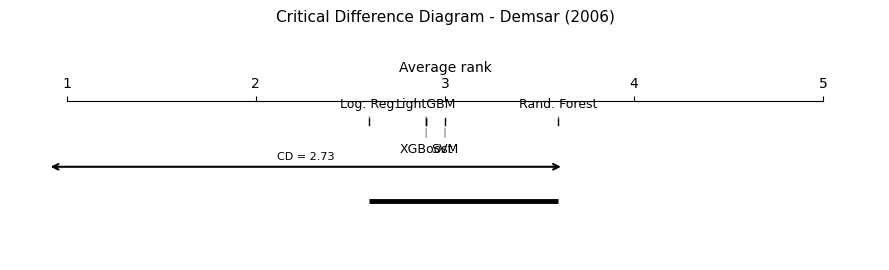

Saved: cd_diagram.png


In [29]:
# ── Demsar (2006) statistical comparison of all 5 classifiers ─────────────────
# Friedman test + Nemenyi post-hoc + Critical Difference diagram
# Each CV fold is treated as one "dataset" in Demsar's framework.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# q_alpha critical values (alpha=0.05), Demsar (2006) Table 5
_nemenyi_q = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
              7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164}

# ── Collect per-fold macro-F1 ──────────────────────────────────────────────────
_smote = SMOTE(random_state=42, k_neighbors=1)

_classifiers = {
    'XGBoost':      lambda: XGBClassifier(tree_method='hist', device='cpu',
                                          random_state=42, **xgb_best),
    'LightGBM':     lambda: lgb.LGBMClassifier(random_state=42,
                                               class_weight='balanced',
                                               verbose=-1, **lgb_best),
    'Log. Reg.':    lambda: LogisticRegression(random_state=42, **lr_best),
    'Rand. Forest': lambda: RandomForestClassifier(random_state=42, **rf_best),
    'SVM':          lambda: SVC(kernel='rbf', random_state=42, **svm_best),
}

_scores = {name: [] for name in _classifiers}

for _split in splits:
    _Xtr, _ytr = _smote.fit_resample(_split['X_train'], _split['y_train'])
    _Xte, _yte = _split['X_test'], _split['y_test']
    for _name, _build in _classifiers.items():
        _clf = _build()
        _clf.fit(_Xtr, _ytr)
        _scores[_name].append(f1_score(_yte, _clf.predict(_Xte), average='macro'))

scores_df = pd.DataFrame(_scores)   # (N_folds x N_classifiers)
N = len(scores_df)
k = len(scores_df.columns)

print("Per-fold macro-F1 scores:")
print(scores_df.round(4).to_string())
print(f"\nMean macro-F1:\n{scores_df.mean().sort_values(ascending=False).round(4)}")

# ── Friedman test ──────────────────────────────────────────────────────────────
stat, p_val = friedmanchisquare(*[scores_df[c] for c in scores_df.columns])
print(f"\nFriedman test  chi2({k-1}) = {stat:.4f},  p = {p_val:.4f}")
if p_val < 0.05:
    print("  -> Significant differences found (p < 0.05). Proceeding to Nemenyi post-hoc.")
else:
    print("  -> No significant differences (p >= 0.05). Nemenyi test shown for reference.")

# ── Average ranks (1 = best per fold) ─────────────────────────────────────────
ranks_df  = scores_df.rank(axis=1, ascending=False, method='average')
avg_ranks = ranks_df.mean().sort_values()

print("\nAverage ranks (1 = best):")
for clf, r in avg_ranks.items():
    print(f"  {clf:<14} {r:.4f}")

# ── Nemenyi critical difference ────────────────────────────────────────────────
CD = _nemenyi_q[k] * np.sqrt(k * (k + 1) / (6 * N))
print(f"\nNemenyi CD (alpha=0.05, k={k}, N={N}):  CD = {CD:.4f}")

clf_names = list(avg_ranks.index)
print(f"\nPairwise |delta_rank|  (* = significantly different, CD={CD:.3f}):")
header = f"{'':>14}" + "".join(f"{n:>14}" for n in clf_names)
print(header)
for n1 in clf_names:
    row = f"{n1:>14}"
    for n2 in clf_names:
        d = abs(avg_ranks[n1] - avg_ranks[n2])
        sig = '*' if (d > CD and n1 != n2) else ' '
        row += f"  {d:>9.3f}{sig}  "
    print(row)

# ── Critical Difference diagram ────────────────────────────────────────────────
sorted_names = list(avg_ranks.index)
sorted_vals  = [avg_ranks[n] for n in sorted_names]

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.set_xlim(0.7, k + 0.3)
ax.set_ylim(-0.5, 1.8)
ax.set_yticks([])
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xticks(range(1, k + 1))
ax.set_xlabel('Average rank', fontsize=10)
for spine in ['left', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.spines['top'].set_bounds(1, k)

for r in sorted_vals:
    ax.plot([r, r], [1.45, 1.55], 'k-', lw=1)

for i, (name, rank) in enumerate(zip(sorted_names, sorted_vals)):
    above = (i % 2 == 0)
    y_text = 1.75 if above else 1.1
    y_tick = 1.55 if above else 1.45
    ax.annotate(name, xy=(rank, y_tick), xytext=(rank, y_text),
                ha='center', va='center', fontsize=9,
                arrowprops=dict(arrowstyle='-', color='grey', lw=0.8))

cd_x0 = 0.9
ax.annotate('', xy=(cd_x0 + CD, 0.85), xytext=(cd_x0, 0.85),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(cd_x0 + CD / 2, 0.95, f'CD = {CD:.2f}', ha='center', fontsize=8)

y_bar = 0.35
drawn = []
for i in range(k):
    j = i
    while j + 1 < k and (sorted_vals[j + 1] - sorted_vals[i]) <= CD:
        j += 1
    if j > i:
        seg = (i, j)
        if not any(a <= i and j <= b for (a, b) in drawn):
            drawn.append(seg)
            ax.plot([sorted_vals[i], sorted_vals[j]], [y_bar, y_bar],
                    'k-', lw=3.5, solid_capstyle='butt', zorder=3)
            y_bar -= 0.13

plt.title("Critical Difference Diagram - Demsar (2006)", fontsize=11, pad=28)
plt.tight_layout()
plt.savefig("cd_diagram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cd_diagram.png")


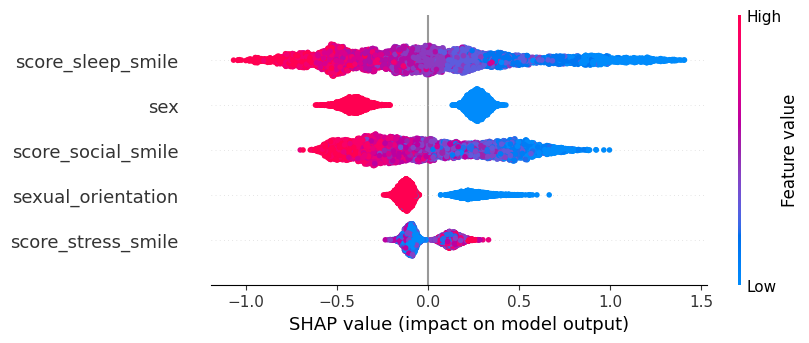

<Figure size 640x480 with 0 Axes>

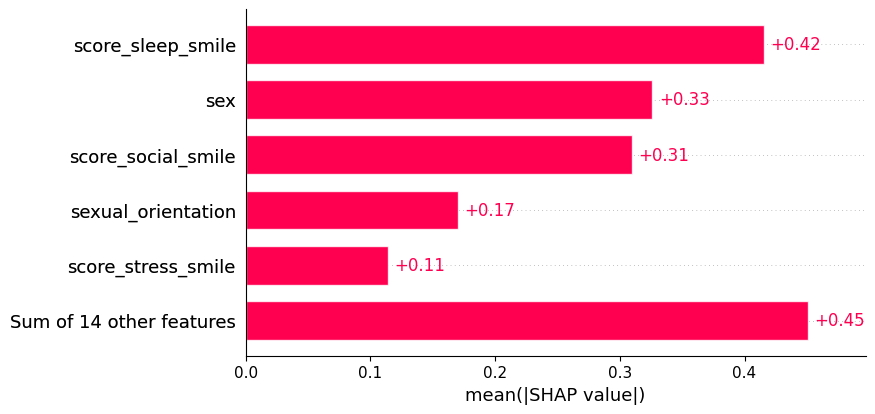

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

smile_variable_groups = {
    "score_food_smile":   ["smile_2", "smile_3", "smile_5"],
    "score_subs_smile":   ["smile_8", "smile_9", "smile_10", "smile_11"],
    "score_PA_smile":     ["smile_12", "smile_13", "smile_15"],
    "score_stress_smile": ["smile_17", "smile_19"],
    "score_sleep_smile":  ["smile_25", "smile_27", "smile_28", "smile_41"],
    "score_social_smile": ["smile_30", "smile_31", "smile_32", "smile_34", "smile_37"],
    "score_envir_smile":  ["smile_40", "smile_42", "smile_43"],
}
feature_to_group_map = {f: g for g, feats in smile_variable_groups.items() for f in feats}

def aggregate_features(feature_name):
    if feature_name in feature_to_group_map:
        return feature_to_group_map[feature_name]
    for prefix in sorted(one_hotted, key=len, reverse=True):
        if feature_name.startswith(prefix):
            return prefix
    return feature_name

def build_display_data(shap_df_agg, X_og_sub, X_num_orig_sub):
    """Reconstruct original-scale feature values for SHAP display.

    - gender_identity / sexual_orientation: dichotomous mask (0 vs other)
    - other one-hot categoricals: original category code from X_og
    - smile groups: sum of original Likert items
    - standalone numericals: imputed original value
    """
    cols = []
    for col_group in shap_df_agg.columns:
        if col_group == 'gender_identity':
            vals = X_og_sub.index.isin(gender_dicotomico_indexes).astype(float)
        elif col_group == 'sexual_orientation':
            vals = X_og_sub.index.isin(sexual_dicotomico_indexes).astype(float)
        elif col_group in one_hotted:
            vals = X_og_sub[col_group].fillna(0).values.astype(float)
        elif col_group in smile_variable_groups:
            group_cols = [c for c in smile_variable_groups[col_group] if c in X_num_orig_sub.columns]
            vals = X_num_orig_sub[group_cols].sum(axis=1).values
        else:
            vals = X_num_orig_sub[col_group].values
        cols.append(vals)
    return pd.DataFrame(np.column_stack(cols), columns=shap_df_agg.columns, index=X_og_sub.index)

# Build stacked test sets
X_test_all     = pd.concat([split['X_test'] for split in splits], axis=0)
X_og_all       = pd.concat([split['X_test_og'] for split in splits], axis=0)
X_num_orig_all = pd.concat([split['X_test_num_orig'] for split in splits], axis=0)

sv = np.vstack(all_shap_values)
if sv.ndim != 2:
    raise ValueError(f"Expected 2D SHAP matrix, got shape {sv.shape}")
if sv.shape[0] != X_test_all.shape[0]:
    raise ValueError(f"Row mismatch: SHAP rows={sv.shape[0]} vs X_test rows={X_test_all.shape[0]}")

sv_df  = pd.DataFrame(sv, columns=X_test_all.columns, index=X_test_all.index)
sv_agg = sv_df.T.groupby(aggregate_features).sum().T

X_display = build_display_data(sv_agg, X_og_all, X_num_orig_all)

expl = shap.Explanation(
    values=sv_agg.values,
    data=X_display[sv_agg.columns].values,
    feature_names=list(sv_agg.columns),
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(expl, max_display=5, group_remaining_features=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.bar(expl, max_display=6)
plt.tight_layout()
plt.show()


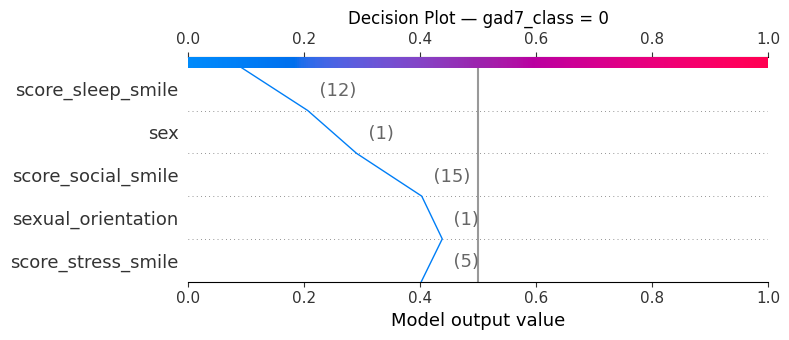

Saved: decision_plot_class0.png


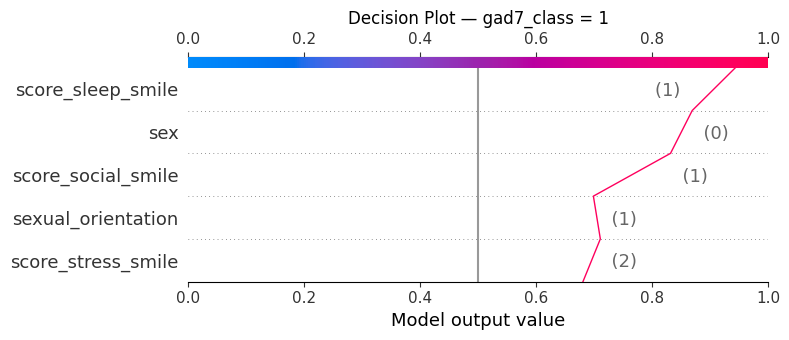

Saved: decision_plot_class1.png


In [15]:
# ── Local XAI: Decision Plots (single-observation) ─────────────────────────
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd

# Re-create explainer from last fold's LightGBM model to obtain the base value
explainer_local = shap.TreeExplainer(lgb_clf)
base_value = explainer_local.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(base_value[1] if len(base_value) > 1 else base_value[0])
else:
    base_value = float(base_value)

# Build y series aligned to sv_agg index
y_concat = pd.concat([split["y_test"] for split in splits])
y_concat = y_concat[~y_concat.index.duplicated(keep="first")]
common_idx = sv_agg.index.intersection(y_concat.index)
y_aligned = y_concat.loc[common_idx]

# Estimated log-odds for each observation (base + sum of SHAP values)
log_odds = (base_value + sv_agg.sum(axis=1)).loc[common_idx]

# Pick the most extreme observations: lowest log-odds for class 0,
# highest log-odds for class 1 — so predictions are far from 0.5
idx_class0 = log_odds[y_aligned == 0].idxmin()
idx_class1 = log_odds[y_aligned == 1].idxmax()

feat_cols = list(sv_agg.columns)

# Global feature order: ascending mean |SHAP| so the top 5 land at the end
# and feature_display_range=slice(-1, -6, -1) shows the same features in both plots
global_order = sv_agg.abs().mean().sort_values(ascending=True).index.tolist()
global_order_idx = [feat_cols.index(f) for f in global_order]

for idx, class_label in [(idx_class0, 0), (idx_class1, 1)]:
    row_sv   = sv_agg.loc[idx]
    row_feat = X_display.loc[idx]
    # Guard against duplicate index returning a DataFrame
    if isinstance(row_sv, pd.DataFrame):
        row_sv = row_sv.iloc[0]
    if isinstance(row_feat, pd.DataFrame):
        row_feat = row_feat.iloc[0]

    plt.figure(figsize=(9, 5))
    shap.decision_plot(
        base_value,
        row_sv.values,
        row_feat.values,
        feature_names=feat_cols,
        feature_order=global_order_idx,   # fixed global importance order
        feature_display_range=slice(-1, -6, -1),  # same top 5 in both plots
        link="logit",
        xlim=[0, 1],
        show=False,
    )
    plt.title(f"Decision Plot — gad7_class = {class_label}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"decision_plot_class{class_label}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: decision_plot_class{class_label}.png")


In [10]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

os.makedirs("regions_shap", exist_ok=True)

all_shap_list    = []
all_X_test_list  = []
all_X_og_list    = []
all_X_num_orig_list = []
all_shap_array   = np.vstack(all_shap_values)
cursor = 0

for i, split in enumerate(splits):
    X_test = split['X_test'].copy()
    n_rows = len(X_test)
    shap_vals = all_shap_array[cursor:cursor + n_rows]
    cursor += n_rows

    if isinstance(shap_vals, shap.Explanation):
        shap_array = shap_vals.values
    elif isinstance(shap_vals, list):
        shap_array = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
    elif isinstance(shap_vals, pd.DataFrame):
        shap_array = shap_vals.values
    else:
        shap_array = np.asarray(shap_vals)
        if shap_array.ndim == 3:
            shap_array = shap_array[:, :, 1]

    if shap_array.ndim == 1:
        shap_array = shap_array.reshape(1, -1)

    shap_df = pd.DataFrame(shap_array, columns=X_test.columns, index=X_test.index)
    all_shap_list.append(shap_df)
    all_X_test_list.append(X_test)
    all_X_og_list.append(split['X_test_og'])
    all_X_num_orig_list.append(split['X_test_num_orig'])

shap_df_all    = pd.concat(all_shap_list,       axis=0, ignore_index=False)
X_test_all     = pd.concat(all_X_test_list,     axis=0, ignore_index=False)
X_og_all       = pd.concat(all_X_og_list,       axis=0, ignore_index=False)
X_num_orig_all = pd.concat(all_X_num_orig_list, axis=0, ignore_index=False)

# ── Per-region SHAP plots ─────────────────────────────────────────────────────
for code, region_name in enumerate(REGION_NAMES):
    region_idx  = region_indexes[code]
    region_mask = shap_df_all.index.isin(region_idx)

    shap_df_region  = shap_df_all.loc[region_mask]
    X_og_region     = X_og_all.loc[region_mask]
    X_num_orig_region = X_num_orig_all.loc[region_mask]

    if len(shap_df_region) == 0:
        print(f"[{region_name}] No test samples — skipping.")
        continue

    print(f"\n── Region: {region_name} (n={len(shap_df_region)}) ──")

    shap_df_agg  = shap_df_region.T.groupby(aggregate_features).sum().T
    shap_df_agg  = shap_df_agg.drop(columns=['region', 'course'], errors='ignore')
    common_cols  = list(shap_df_agg.columns)

    X_display = build_display_data(shap_df_agg, X_og_region, X_num_orig_region)[common_cols]

    slug = region_name.replace(" ", "_").lower()
    expl = shap.Explanation(
        values=shap_df_agg.values,
        data=X_display.values,
        feature_names=common_cols,
    )

    plt.figure(figsize=(10, 8))
    plt.title(f"SHAP Beeswarm — {region_name}", fontsize=14, pad=12)
    shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False, show=False)
    plt.tight_layout()
    plt.savefig(f"regions_shap/{slug}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Bar — {region_name}", fontsize=14, pad=12)
    shap.plots.bar(expl, max_display=30, show=False)
    plt.tight_layout()
    plt.savefig(f"regions_shap/{slug}_bar.png", dpi=150, bbox_inches="tight")
    plt.close()



── Region: center-west (n=335) ──

── Region: north (n=257) ──

── Region: northeast (n=2788) ──

── Region: south (n=918) ──

── Region: southeast (n=1412) ──


In [11]:

# ── Merged-region SHAP plots ──────────────────────────────────────────────────
# Sul+Sudeste  (south=3, southeast=4)
# Norte+Nordeste+Centro-Oeste  (north=1, northeast=2, center-west=0)

MERGED_REGIONS = [
    {
        "name": "Sul+Sudeste",
        "slug": "sul_sudeste",
        "codes": [3, 4],       # south, southeast
    },
    {
        "name": "Norte+Nordeste+Centro-Oeste",
        "slug": "norte_nordeste_centro_oeste",
        "codes": [1, 2, 0],    # north, northeast, center-west
    },
]

for group in MERGED_REGIONS:
    # Collect all original-df indexes that belong to this merged group
    merged_idx = []
    for code in group["codes"]:
        merged_idx.extend(region_indexes[code])

    region_mask = shap_df_all.index.isin(merged_idx)

    shap_df_region    = shap_df_all.loc[region_mask]
    X_og_region       = X_og_all.loc[region_mask]
    X_num_orig_region = X_num_orig_all.loc[region_mask]

    if len(shap_df_region) == 0:
        print(f"[{group['name']}] No test samples — skipping.")
        continue

    print(f"\n── Region: {group['name']} (n={len(shap_df_region)}) ──")

    shap_df_agg = shap_df_region.T.groupby(aggregate_features).sum().T
    shap_df_agg = shap_df_agg.drop(columns=['region', 'course'], errors='ignore')
    common_cols = list(shap_df_agg.columns)

    X_display = build_display_data(shap_df_agg, X_og_region, X_num_orig_region)[common_cols]

    expl = shap.Explanation(
        values=shap_df_agg.values,
        data=X_display.values,
        feature_names=common_cols,
    )

    plt.figure(figsize=(10, 8))
    plt.title(f"SHAP Beeswarm — {group['name']}", fontsize=14, pad=12)
    shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False, show=False)
    plt.tight_layout()
    plt.savefig(f"regions_shap/{group['slug']}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Bar — {group['name']}", fontsize=14, pad=12)
    shap.plots.bar(expl, max_display=30, show=False)
    plt.tight_layout()
    plt.savefig(f"regions_shap/{group['slug']}_bar.png", dpi=150, bbox_inches="tight")
    plt.close()



── Region: Sul+Sudeste (n=2330) ──

── Region: Norte+Nordeste+Centro-Oeste (n=3380) ──


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

os.makedirs("courses_shap", exist_ok=True)

COURSE_NAMES = {
    0: "Ciências Exatas e da Terra",
    1: "Engenharias",
    2: "Ciências Biológicas",
    3: "Ciências da Saúde",
    4: "Ciências Agrárias",
    5: "Ciências Humanas",
    6: "Ciências Sociais Aplicadas",
    7: "Linguística, Letras e Artes",
}

COURSE_SLUGS = {
    0: "exatas_terra",
    1: "engenharias",
    2: "biologicas",
    3: "saude",
    4: "agrarias",
    5: "humanas",
    6: "sociais_aplicadas",
    7: "ling_letras_artes",
}

# Build course indexes (original df indexes per course value)
course_values = sorted(df['course'].dropna().unique().astype(int).tolist())
max_course = max(course_values)

course_indexes = {
    c: df.index[df['course'] == c].tolist()
    for c in course_values
    if c != max_course
}

print(f"Courses to plot (excluding max={max_course}):")
for c, idxs in sorted(course_indexes.items()):
    print(f"  {c} — {COURSE_NAMES.get(c, f'Course {c}')}: {len(idxs)}")

# ── Per-course SHAP plots ─────────────────────────────────────────────────────
for course_val, course_idx in sorted(course_indexes.items()):
    course_mask = shap_df_all.index.isin(course_idx)

    shap_df_course = shap_df_all.loc[course_mask]
    X_test_course = X_test_all.loc[course_mask]

    course_name = COURSE_NAMES.get(course_val, f"Course {course_val}")
    slug = COURSE_SLUGS.get(course_val, f"course_{course_val}")

    if len(shap_df_course) == 0:
        print(f"[{course_name}] No test samples — skipping.")
        continue

    print(f"\n── {course_name} (n={len(shap_df_course)}) ──")

    shap_df_agg = shap_df_course.T.groupby(aggregate_features).sum().T

    X_test_agg_list = []
    for col_group in shap_df_agg.columns:
        group_cols = [c for c in X_test_course.columns if aggregate_features(c) == col_group]

        is_onehot = any(col_group == prefix for prefix in one_hotted)

        if len(group_cols) > 1 and is_onehot:
            X_test_agg_list.append(X_test_course[group_cols].values.argmax(axis=1))
        elif len(group_cols) > 1:
            X_test_agg_list.append(X_test_course[group_cols].mean(axis=1).values)
        else:
            X_test_agg_list.append(X_test_course[col_group].values)

    X_test_agg = pd.DataFrame(
        np.column_stack(X_test_agg_list),
        columns=shap_df_agg.columns,
        index=X_test_course.index
    )

    common_columns = [c for c in shap_df_agg.columns if c != 'course']
    shap_df_agg = shap_df_agg[common_columns]
    X_test_agg = X_test_agg[common_columns]

    if 'gender_identity' in X_test_agg.columns:
        X_test_agg['gender_identity'] = X_test_agg.index.isin(gender_dicotomico_indexes).astype(int)

    if 'sexual_orientation' in X_test_agg.columns:
        X_test_agg['sexual_orientation'] = X_test_agg.index.isin(sexual_dicotomico_indexes).astype(int)

    expl = shap.Explanation(
        values=shap_df_agg.values,
        data=X_test_agg.values,
        feature_names=common_columns
    )

    # Beeswarm
    plt.figure(figsize=(10, 8))
    plt.title(f"SHAP Beeswarm — {course_name}", fontsize=14, pad=12)
    shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False, show=False)
    plt.tight_layout()
    plt.savefig(f"courses_shap/{slug}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.close()

    # Bar summary
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Bar — {course_name}", fontsize=14, pad=12)
    shap.plots.bar(expl, max_display=30, show=False)
    plt.tight_layout()
    plt.savefig(f"courses_shap/{slug}_bar.png", dpi=150, bbox_inches="tight")
    plt.close()
